# Week 9 Phase 2.1 — 4D process inputs + temporal width dynamics

**Does adding temporal melt-pool width dynamics to `[P, VX, LS, ST]` predict `has_keyhole` better than the process parameters alone?**

This notebook reads the generated artifacts. The engine is `src/week9_phase2_1_fourd_plus_width_control.py`.


In [1]:
import json
from pathlib import Path
import pandas as pd
from IPython.display import display, Image
pd.set_option('display.width', 170)
pd.set_option('display.max_columns', 40)
ROOT = Path.cwd().parents[1] if Path.cwd().name == 'week_09' else Path.cwd()
OUT = ROOT / 'outputs' / 'week9_phase2_1_fourd_plus_width_control'
assert OUT.is_dir(), OUT


## 1. What question is being asked?

Phase 2 compared temporal transverse-width dynamics against the scalar physics coordinate `h`. The control Ioan actually asked for was never completed: compare width dynamics against the **four process parameters** `[P, VX, LS, ST]` that are set on the machine. Phase 2.1 is exactly that comparison.

* baseline — `4d_only` = `[P, VX, LS, ST]`
* challenger — `4d_plus_width_dynamics` = `[P, VX, LS, ST]` + the eight Phase 2 width features

Everything else (population, folds, width definition, metric set) is held fixed on purpose.


In [2]:
display(pd.read_csv(OUT/'semantic_width_audit.csv')[['quantity','formula','physical_interpretation','used_in_phase2_1','semantic_source_reverified_now']])


,quantity,formula,physical_interpretation,used_in_phase2_1,semantic_source_reverified_now
0,longitudinal_length,x_max - x_min,longitudinal melt-pool length dX,False,True
1,transverse_width,y_max - y_min,transverse melt-pool width dY,True,True


## 2. Why does it matter?

If width dynamics only beats `h`, that is a weak result: `h` throws away three of the four inputs. A supervisor deciding whether to instrument a machine needs to know whether watching the melt pool tells you anything you did not already know from the parameters you chose. That is a decision-relevant question, and it can be answered cleanly with a transparent classifier.


In [3]:
print((OUT/'claim_ledger.md').read_text(encoding='utf-8').split('## Status vocabulary')[0])


# Week 9 Phase 2.1 claim ledger

Primary question: **does `4d_plus_width_dynamics` beat `4d_only` at predicting `has_keyhole`?**

| claim | status | guardrail |
|---|---|---|
| PRIMARY — the full 8-feature width-dynamics block added to [P, VX, LS, ST] improves hard classification | NOT SUPPORTED | q20 balanced accuracy / Keyhole recall / accuracy; 95% repeat-block CI, Holm-adjusted over six predeclared metrics |
| PRIMARY — the same block improves ranking / probability quality | NOT SUPPORTED | q20 ROC-AUC / PR-AUC / Brier; read separately from the hard metrics |
| The primary verdict is stable across evaluation regions (q20, q30, full) | QUALIFIED | q20: nominal effect on none; q30: nominal effect on brier_score, keyhole_recall, pr_auc; full: nominal effect on brier_score |
| Temporal width dynamics alone can classify the regime | NOT SUPPORTED | width_dynamics_only q20 balanced accuracy = 0.505 (chance = 0.500) |
| SECONDARY — a 3-feature width-SHAPE subset added to [P, VX, LS, ST] i

## 3. What data are used?

The frozen canonical population (405 simulations, 73 Keyhole). Width traces come from Phase 2 commit `da913797` and are **not** re-extracted — the transverse definition ΔY = Ymax − Ymin is inherited byte-for-byte, and ΔX (longitudinal length) is dropped before anything is modelled. Not every simulation has a usable trace, and the loss is structured, so every model — baseline included — is restricted to the same usable subset.


,category,count,keyhole_count,conduction_count,keyhole_fraction,P_mean,VX_mean,LS_mean,ST_mean,standardized_mean_difference_usable_minus_missing
0,usable_transverse_width_trace,350,70.0,280.0,0.200000,213.635364,0.622156,0.000062,350.564439,NaN
1,missing_or_unusable_trace,55,3.0,52.0,0.054545,161.906568,0.628640,0.000064,338.651082,NaN
2,structured_missingness_P,405,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.545516
3,structured_missingness_VX,405,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.027695
4,structured_missingness_LS,405,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.132172
5,structured_missingness_ST,405,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.379458
6,structured_missingness_log_h,405,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.436284


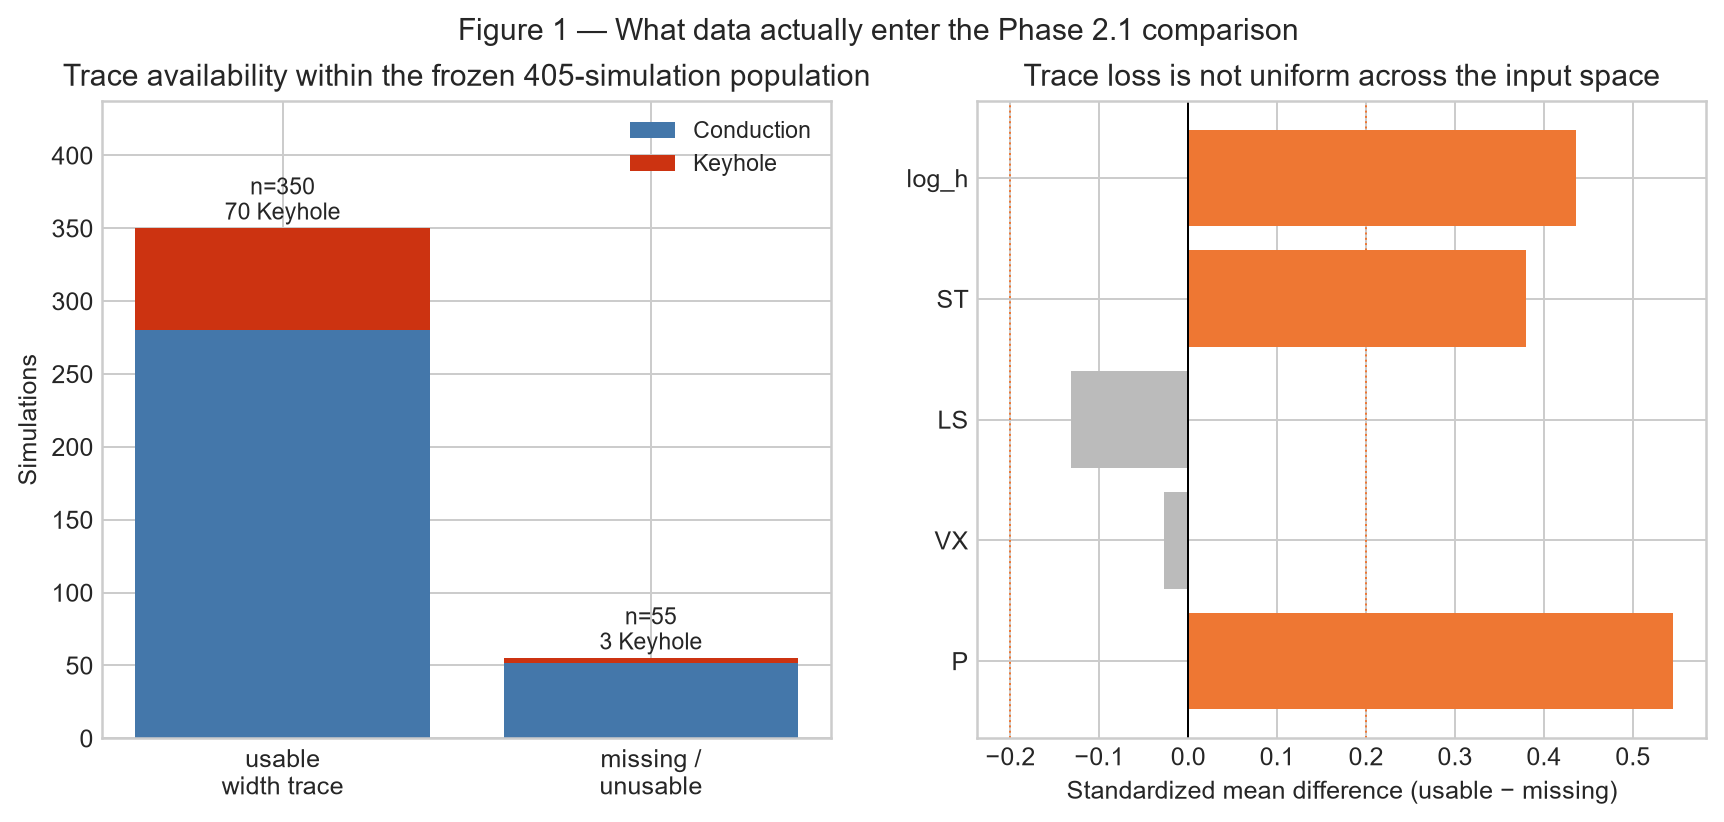

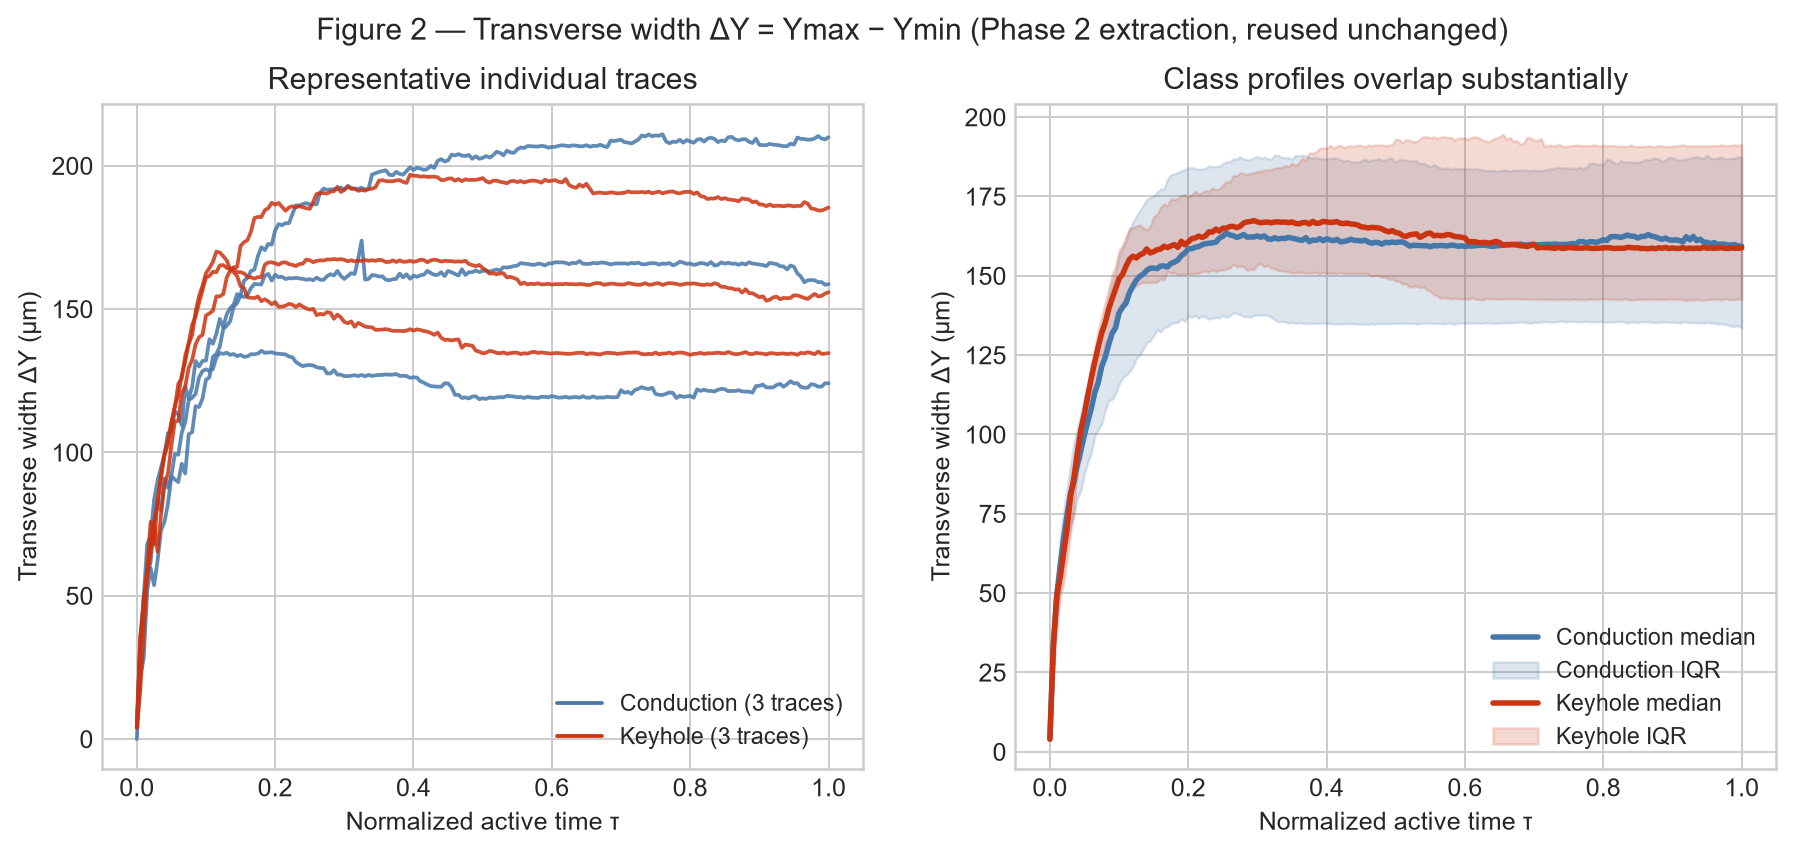

In [4]:
display(pd.read_csv(OUT/'trace_availability_summary.csv'))
display(Image(filename=OUT/'figures'/'01_trace_availability.png'))
display(Image(filename=OUT/'figures'/'02_representative_width_traces.png'))


## 4. What exactly is being compared?

Ten logistic pipelines on the 100 frozen Week 8.5 grouped folds. Scaling and fitting happen inside each training fold; q20/q30 are evaluation-only boundary masks. Five of the ten models exist only to reproduce Phase 2 exactly — that reproduction is the audit anchor that makes the new numbers comparable.


In [5]:
gate = pd.read_csv(OUT/'phase2_reproduction_gate.csv')
print('Phase 2 reproduction rows:', len(gate), '| max abs difference:', gate.abs_difference.max(), '| all PASS:', bool(gate.status.eq('PASS').all()))
display(pd.read_csv(OUT/'feature_integrity_audit.csv'))


Phase 2 reproduction rows: 135 | max abs difference: 1.1102230246251563e-16 | all PASS: True


,quantity,check,max_abs_difference,status
0,P,phase 2 stored value equals canonical populati...,0.000000e+00,PASS
1,VX,phase 2 stored value equals canonical populati...,0.000000e+00,PASS
2,LS,phase 2 stored value equals canonical populati...,0.000000e+00,PASS
3,ST,phase 2 stored value equals canonical populati...,0.000000e+00,PASS
4,log_h,phase 2 stored value equals canonical populati...,3.552714e-15,PASS
5,has_keyhole,phase 2 stored label equals canonical manual l...,0.000000e+00,PASS
6,model_feature_columns,no label-derived or evaluation-mask column ent...,0.000000e+00,PASS
7,longitudinal_columns_dropped,no dX (longitudinal length) column survives in...,0.000000e+00,PASS


## 5. What numbers came out?

Held-out performance across every candidate model, then the single contrast that carries the phase: `4d_plus_width_dynamics − 4d_only`.


metric,balanced_accuracy,brier_score,keyhole_recall,pr_auc,roc_auc
model,,,,,
4d_only,0.8109,0.1205,0.6920,0.8135,0.9073
4d_plus_static_width,0.7999,0.1255,0.6764,0.8058,0.8998
4d_plus_width_dynamics,0.8144,0.1184,0.7021,0.8177,0.9065
4d_plus_width_shape_only,0.8312,0.1118,0.7424,0.8282,0.9217
h_only,0.8210,0.1216,0.7305,0.8069,0.9060
h_plus_width_dynamics,0.8009,0.1204,0.6676,0.8270,0.9076
h_plus_width_shape_only,0.8203,0.1125,0.7205,0.8312,0.9225
static_width,0.5099,0.2677,0.0198,0.4837,0.5404
width_dynamics,0.5054,0.2755,0.0150,0.4460,0.4972


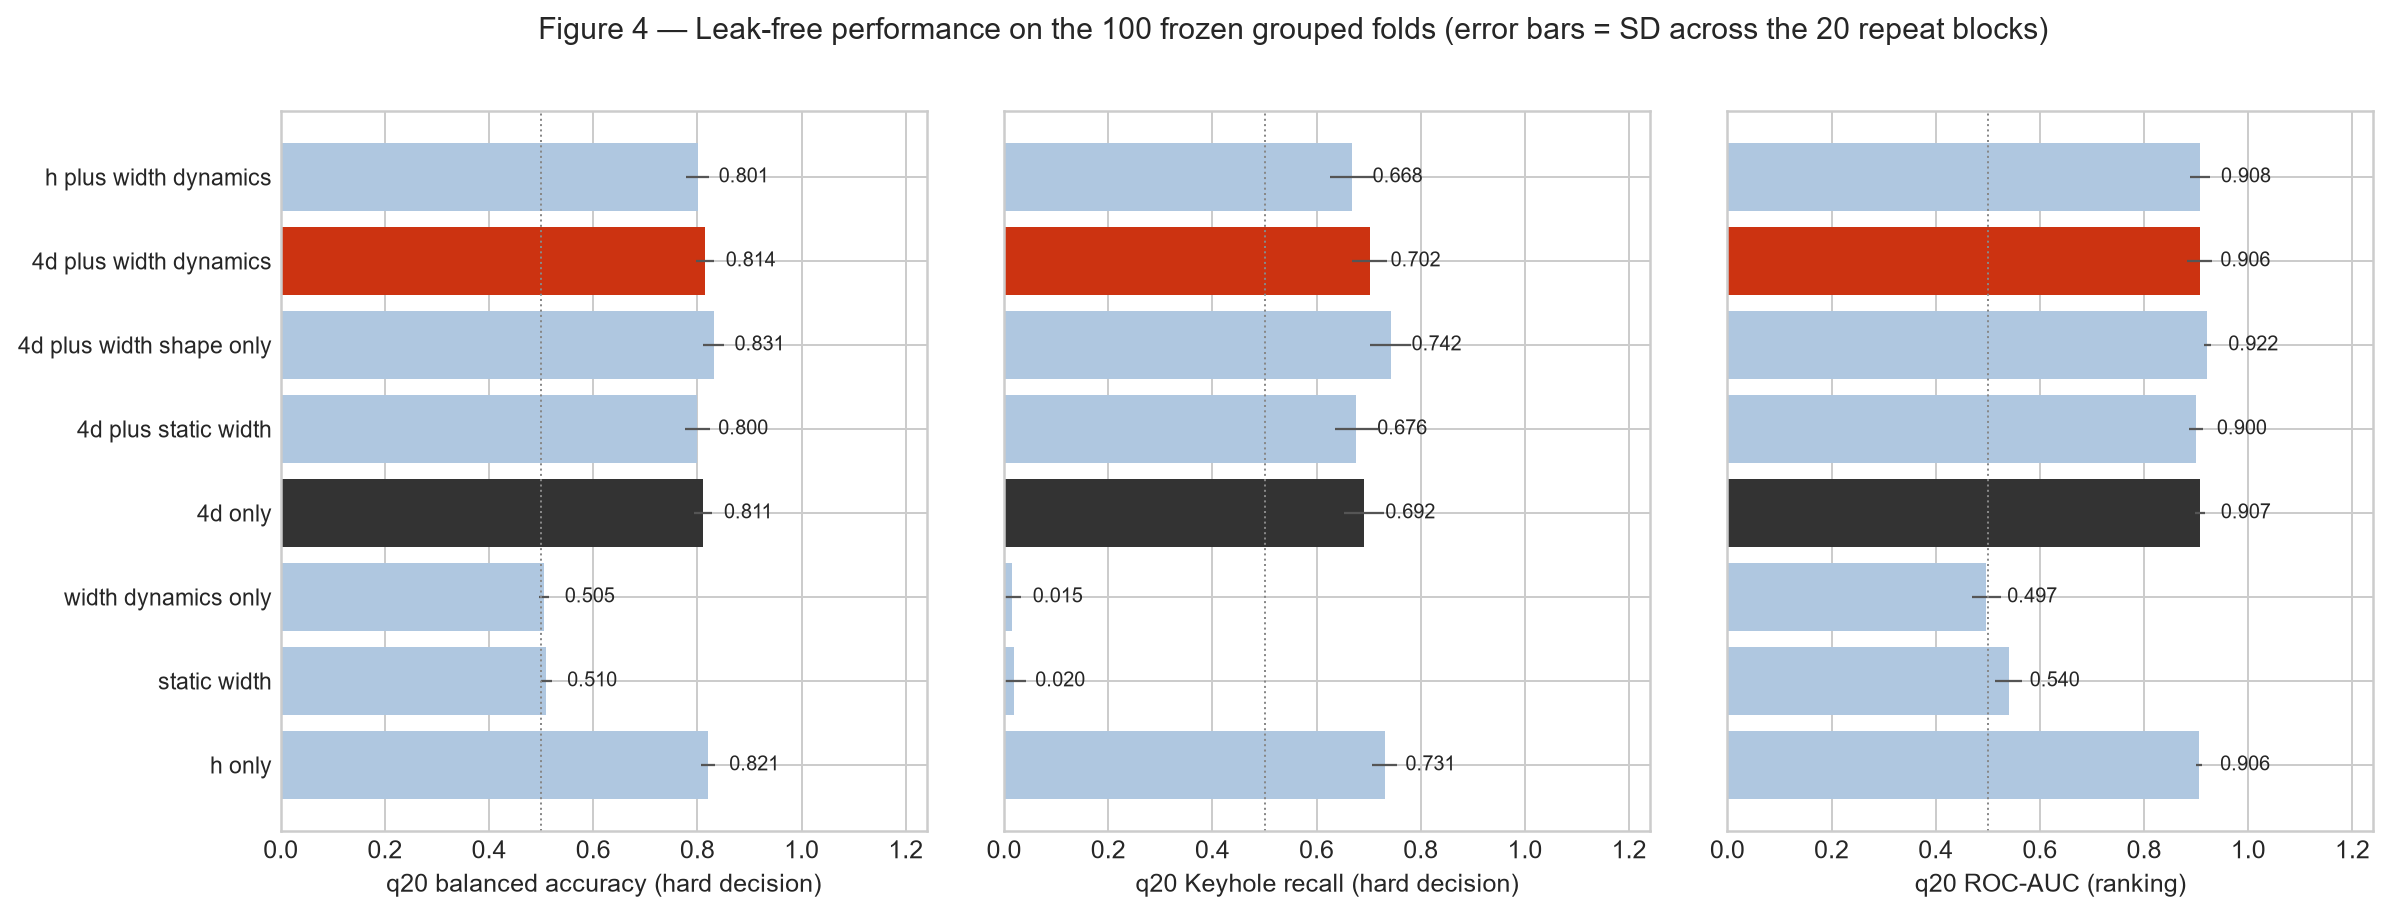

,metric,metric_family,mean_difference,ci_low,ci_high,signflip_p,verdict
6,accuracy,hard_decision,0.001967,-0.003964,0.008523,0.565922,NO DETECTABLE DIFFERENCE
7,balanced_accuracy,hard_decision,0.003467,-0.003715,0.011217,0.400430,NO DETECTABLE DIFFERENCE
8,keyhole_recall,hard_decision,0.010129,-0.001955,0.025055,0.196090,NO DETECTABLE DIFFERENCE
9,brier_score,ranking_or_probability,-0.002127,-0.004985,0.000977,0.191290,NO DETECTABLE DIFFERENCE
10,pr_auc,ranking_or_probability,0.004185,-0.002647,0.010617,0.247288,NO DETECTABLE DIFFERENCE
11,roc_auc,ranking_or_probability,-0.000839,-0.011196,0.008495,0.870706,NO DETECTABLE DIFFERENCE


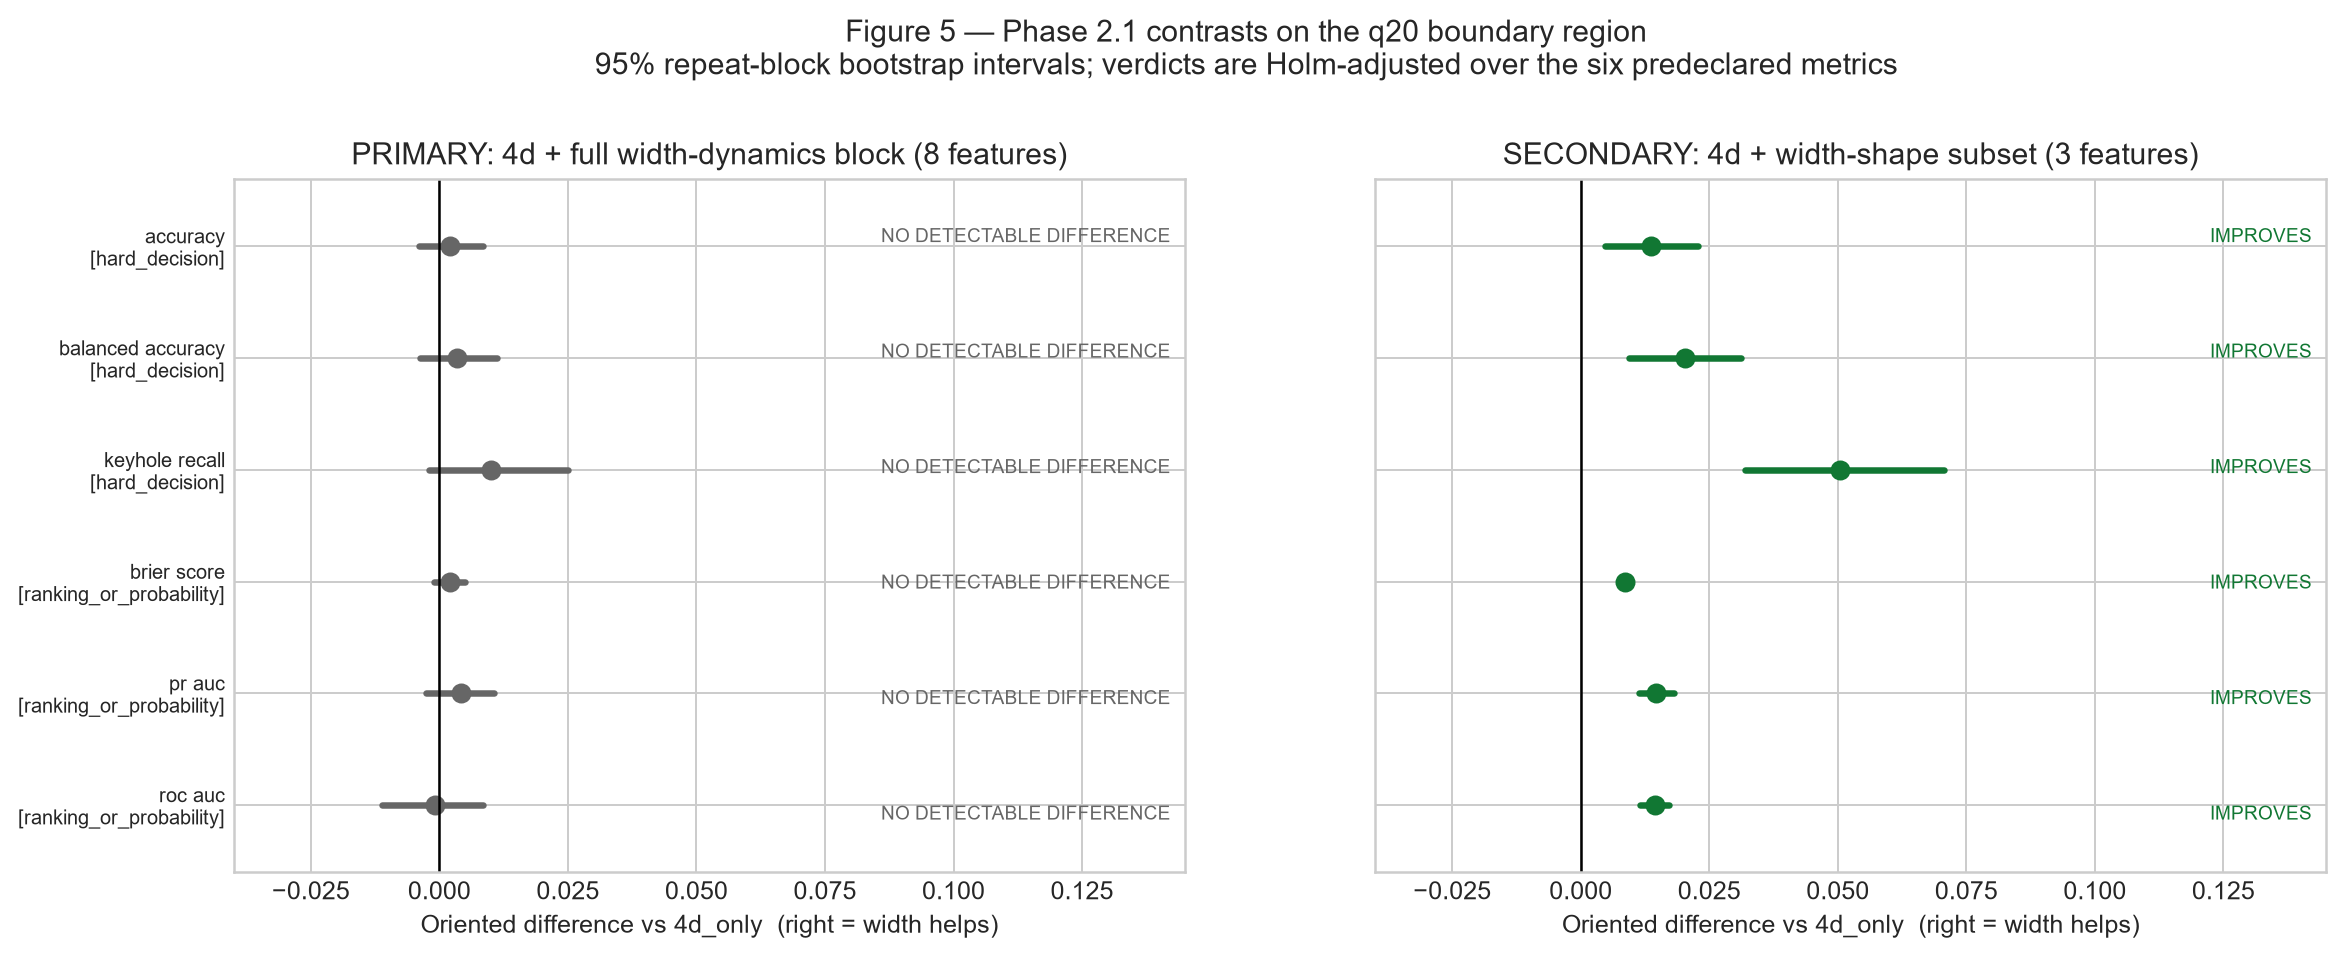

In [6]:
s = pd.read_csv(OUT/'model_oof_summary.csv')
display(s[(s.subset=='q20') & s.metric.isin(['balanced_accuracy','keyhole_recall','roc_auc','pr_auc','brier_score'])].pivot(index='model', columns='metric', values='mean').round(4))
display(Image(filename=OUT/'figures'/'04_model_comparison.png'))
display(pd.read_csv(OUT/'primary_contrast_inference.csv').query("subset=='q20'")[['metric','metric_family','mean_difference','ci_low','ci_high','signflip_p','verdict']])
display(Image(filename=OUT/'figures'/'05_primary_contrast.png'))


## 6. What did we learn?

The mechanism matters more than the number: the width trace is generated by the process parameters, so most of its information is already in `[P, VX, LS, ST]`. The collinearity table and the in-fold coefficients say the same thing from two directions.


,width_feature,r2_explained_by_4d_inputs,spearman_rho_raw_with_label,spearman_rho_residual_with_label,residual_spearman_p,independent_information_retained
0,width_gain_40_um,0.8574,0.1044,-0.2237,0.0000,2.1422
1,robust_max_positive_dWdt_um_per_ms,0.7050,-0.1591,-0.0789,0.1407,0.4960
2,width_gain_20_um,0.6864,0.0827,-0.1777,0.0008,2.1479
3,robust_early_dWdt_40_um_per_ms,0.6523,-0.0109,-0.0720,0.1792,6.6104
4,time_to_50pct_max_width_tau,0.5096,0.1700,-0.0682,0.2034,0.4008
5,robust_early_dWdt_20_um_per_ms,0.4895,0.0727,-0.1422,0.0077,1.9572
6,robust_median_positive_dWdt_um_per_ms,0.2093,-0.1840,0.0355,0.5081,0.1929
7,robust_time_of_max_dWdt_tau,0.0349,-0.0206,-0.1572,0.0032,7.6334


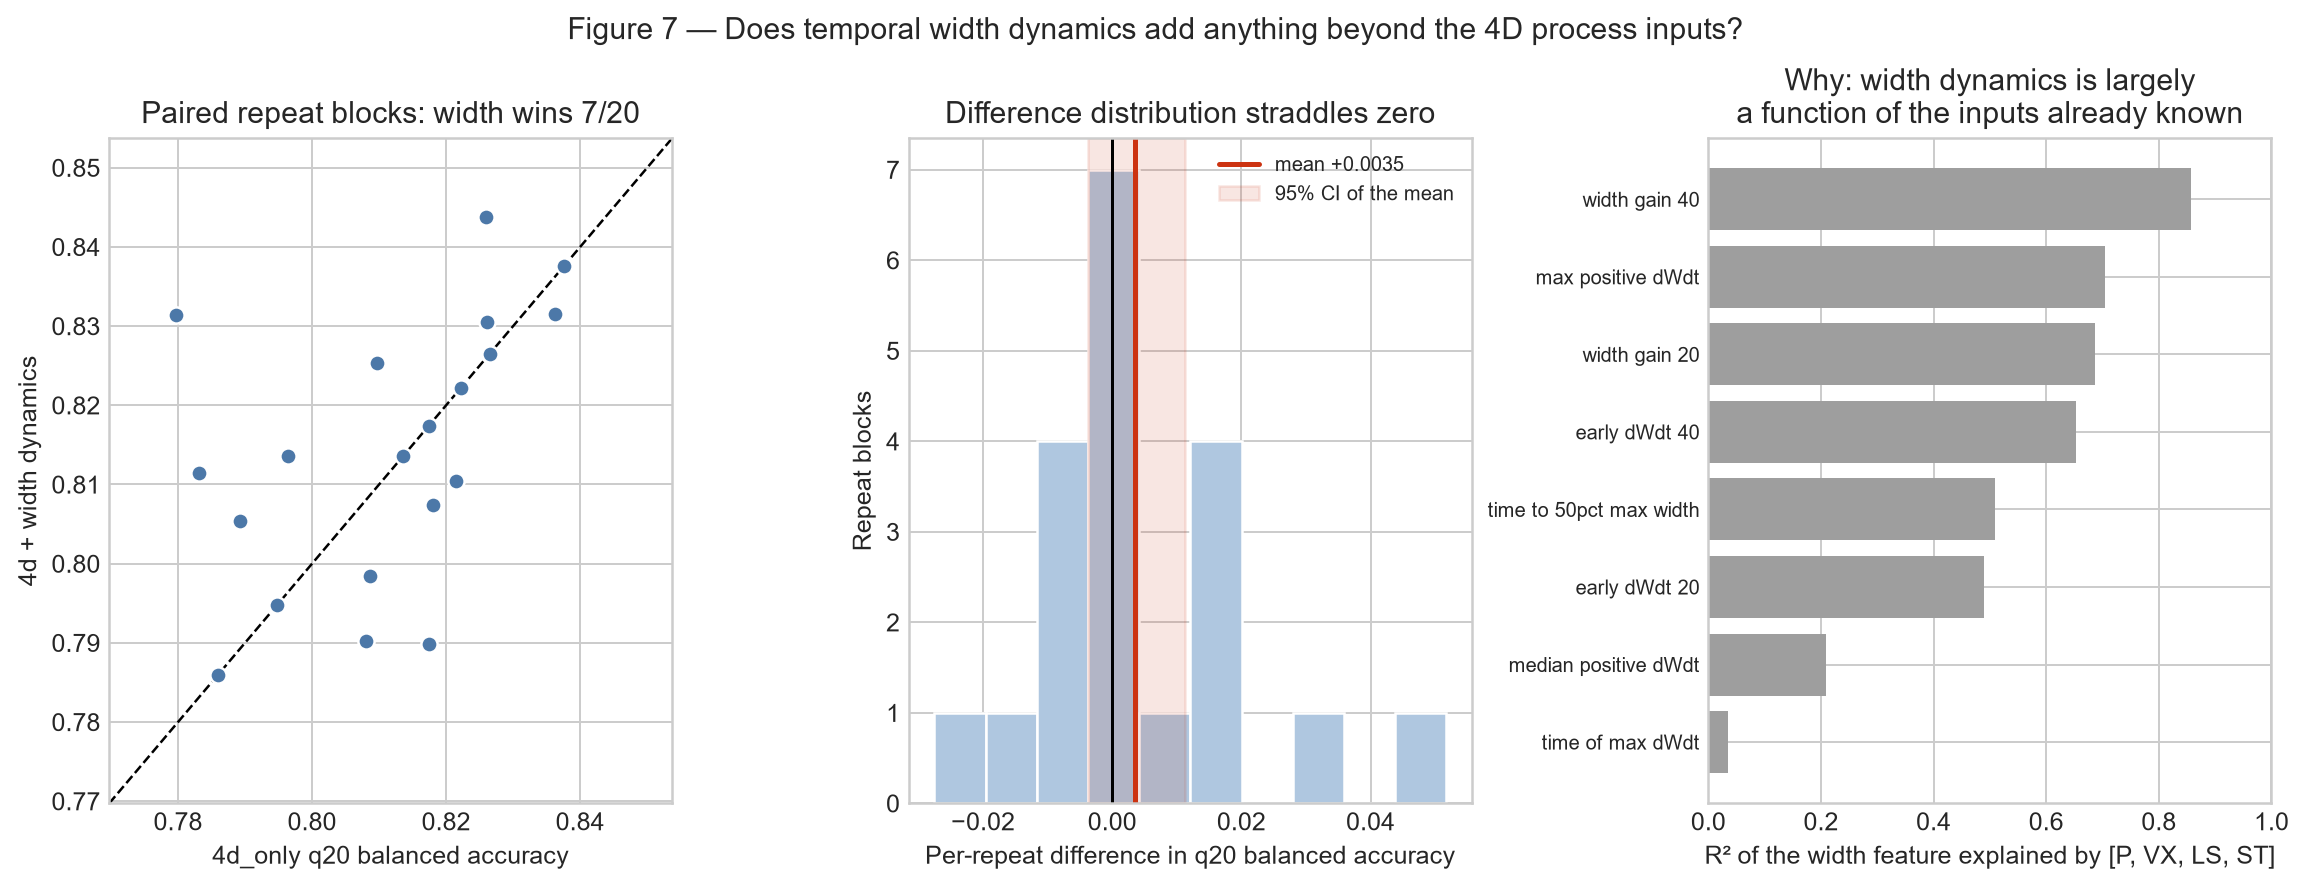

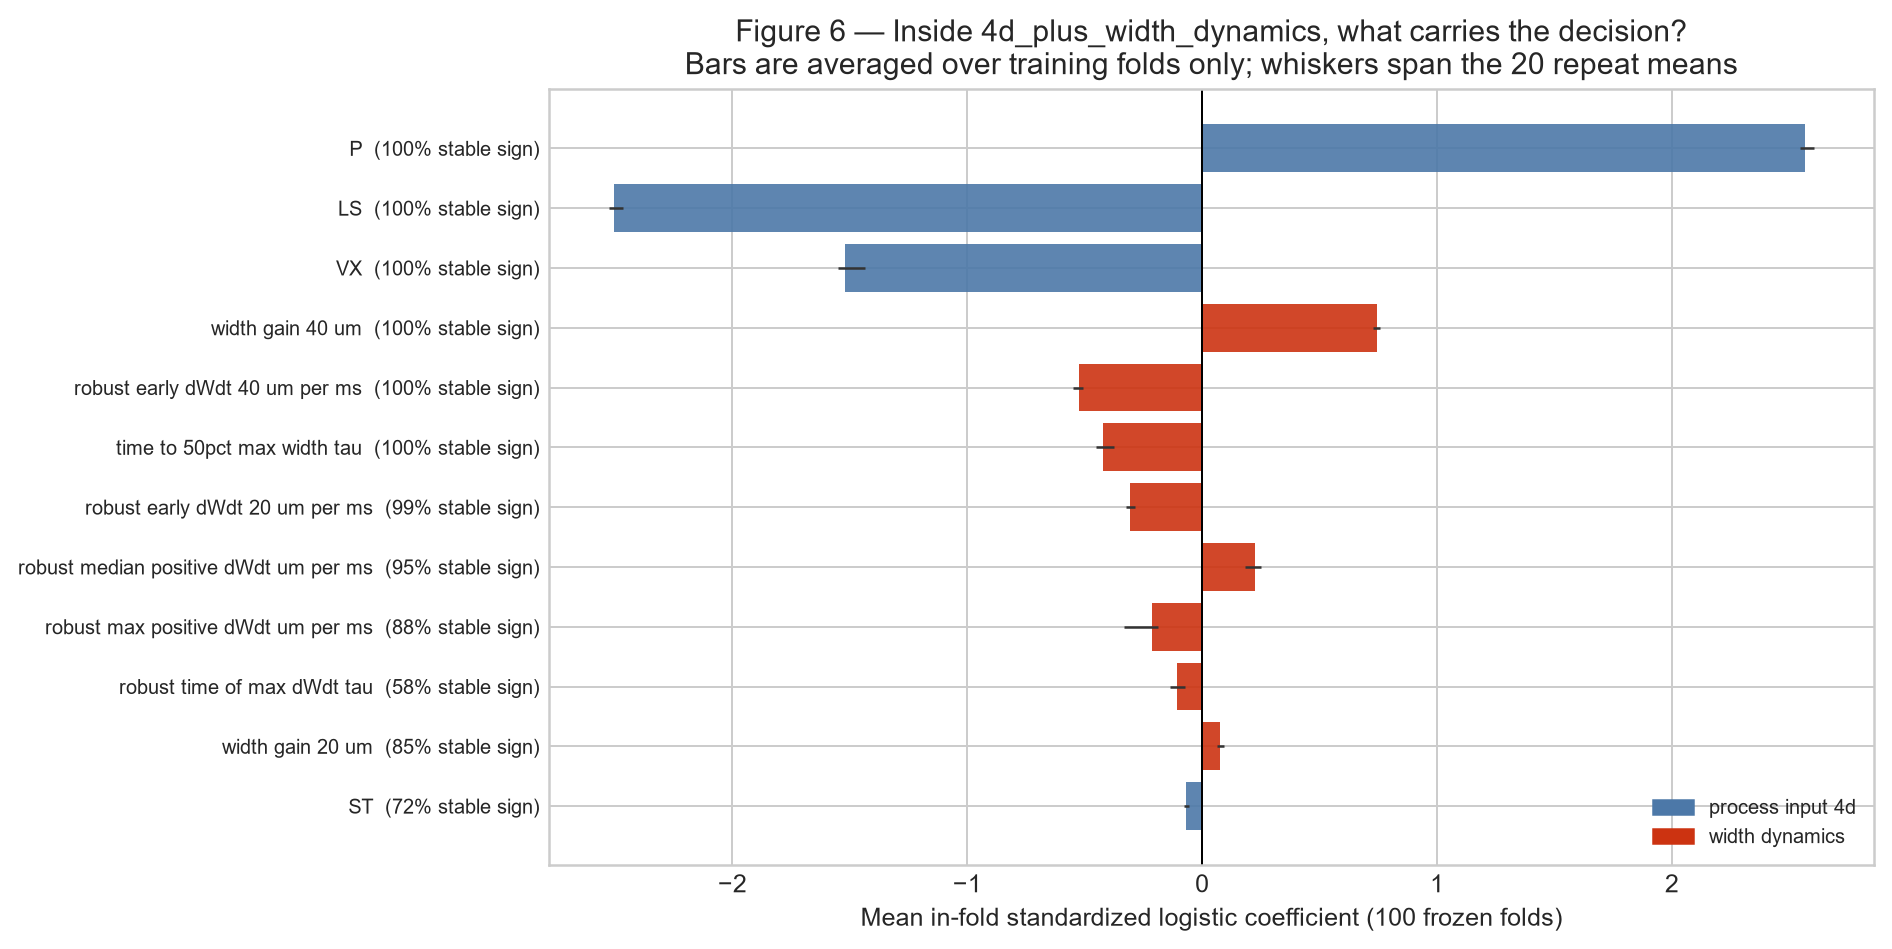

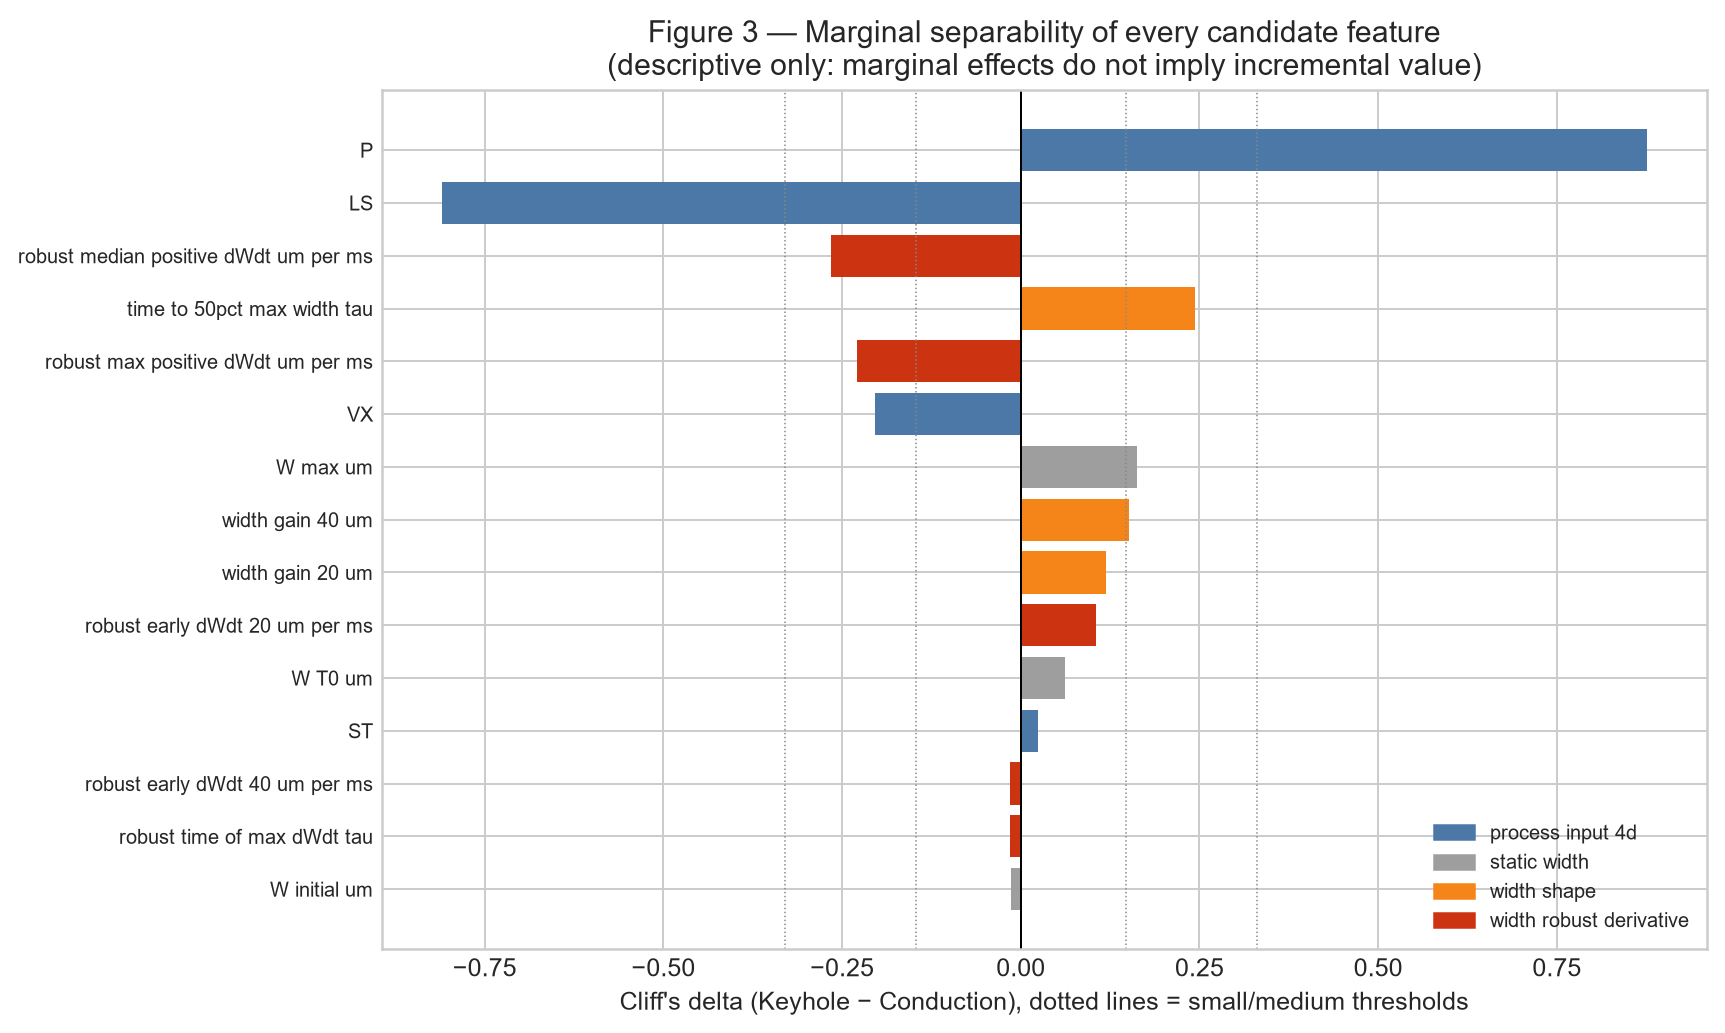

In [7]:
display(pd.read_csv(OUT/'width_vs_4d_collinearity.csv').round(4))
display(Image(filename=OUT/'figures'/'07_does_width_add_beyond_4d.png'))
display(Image(filename=OUT/'figures'/'06_infold_coefficients.png'))
display(Image(filename=OUT/'figures'/'03_width_feature_summary.png'))


## 7. What is supported, what is not, what stays qualitative?

The claim ledger is the contract. A marginal association (Figure 3) is not incremental value; a ranking gain is not a hard-classification gain; and nothing here transfers to the simulations that never produced a usable trace.


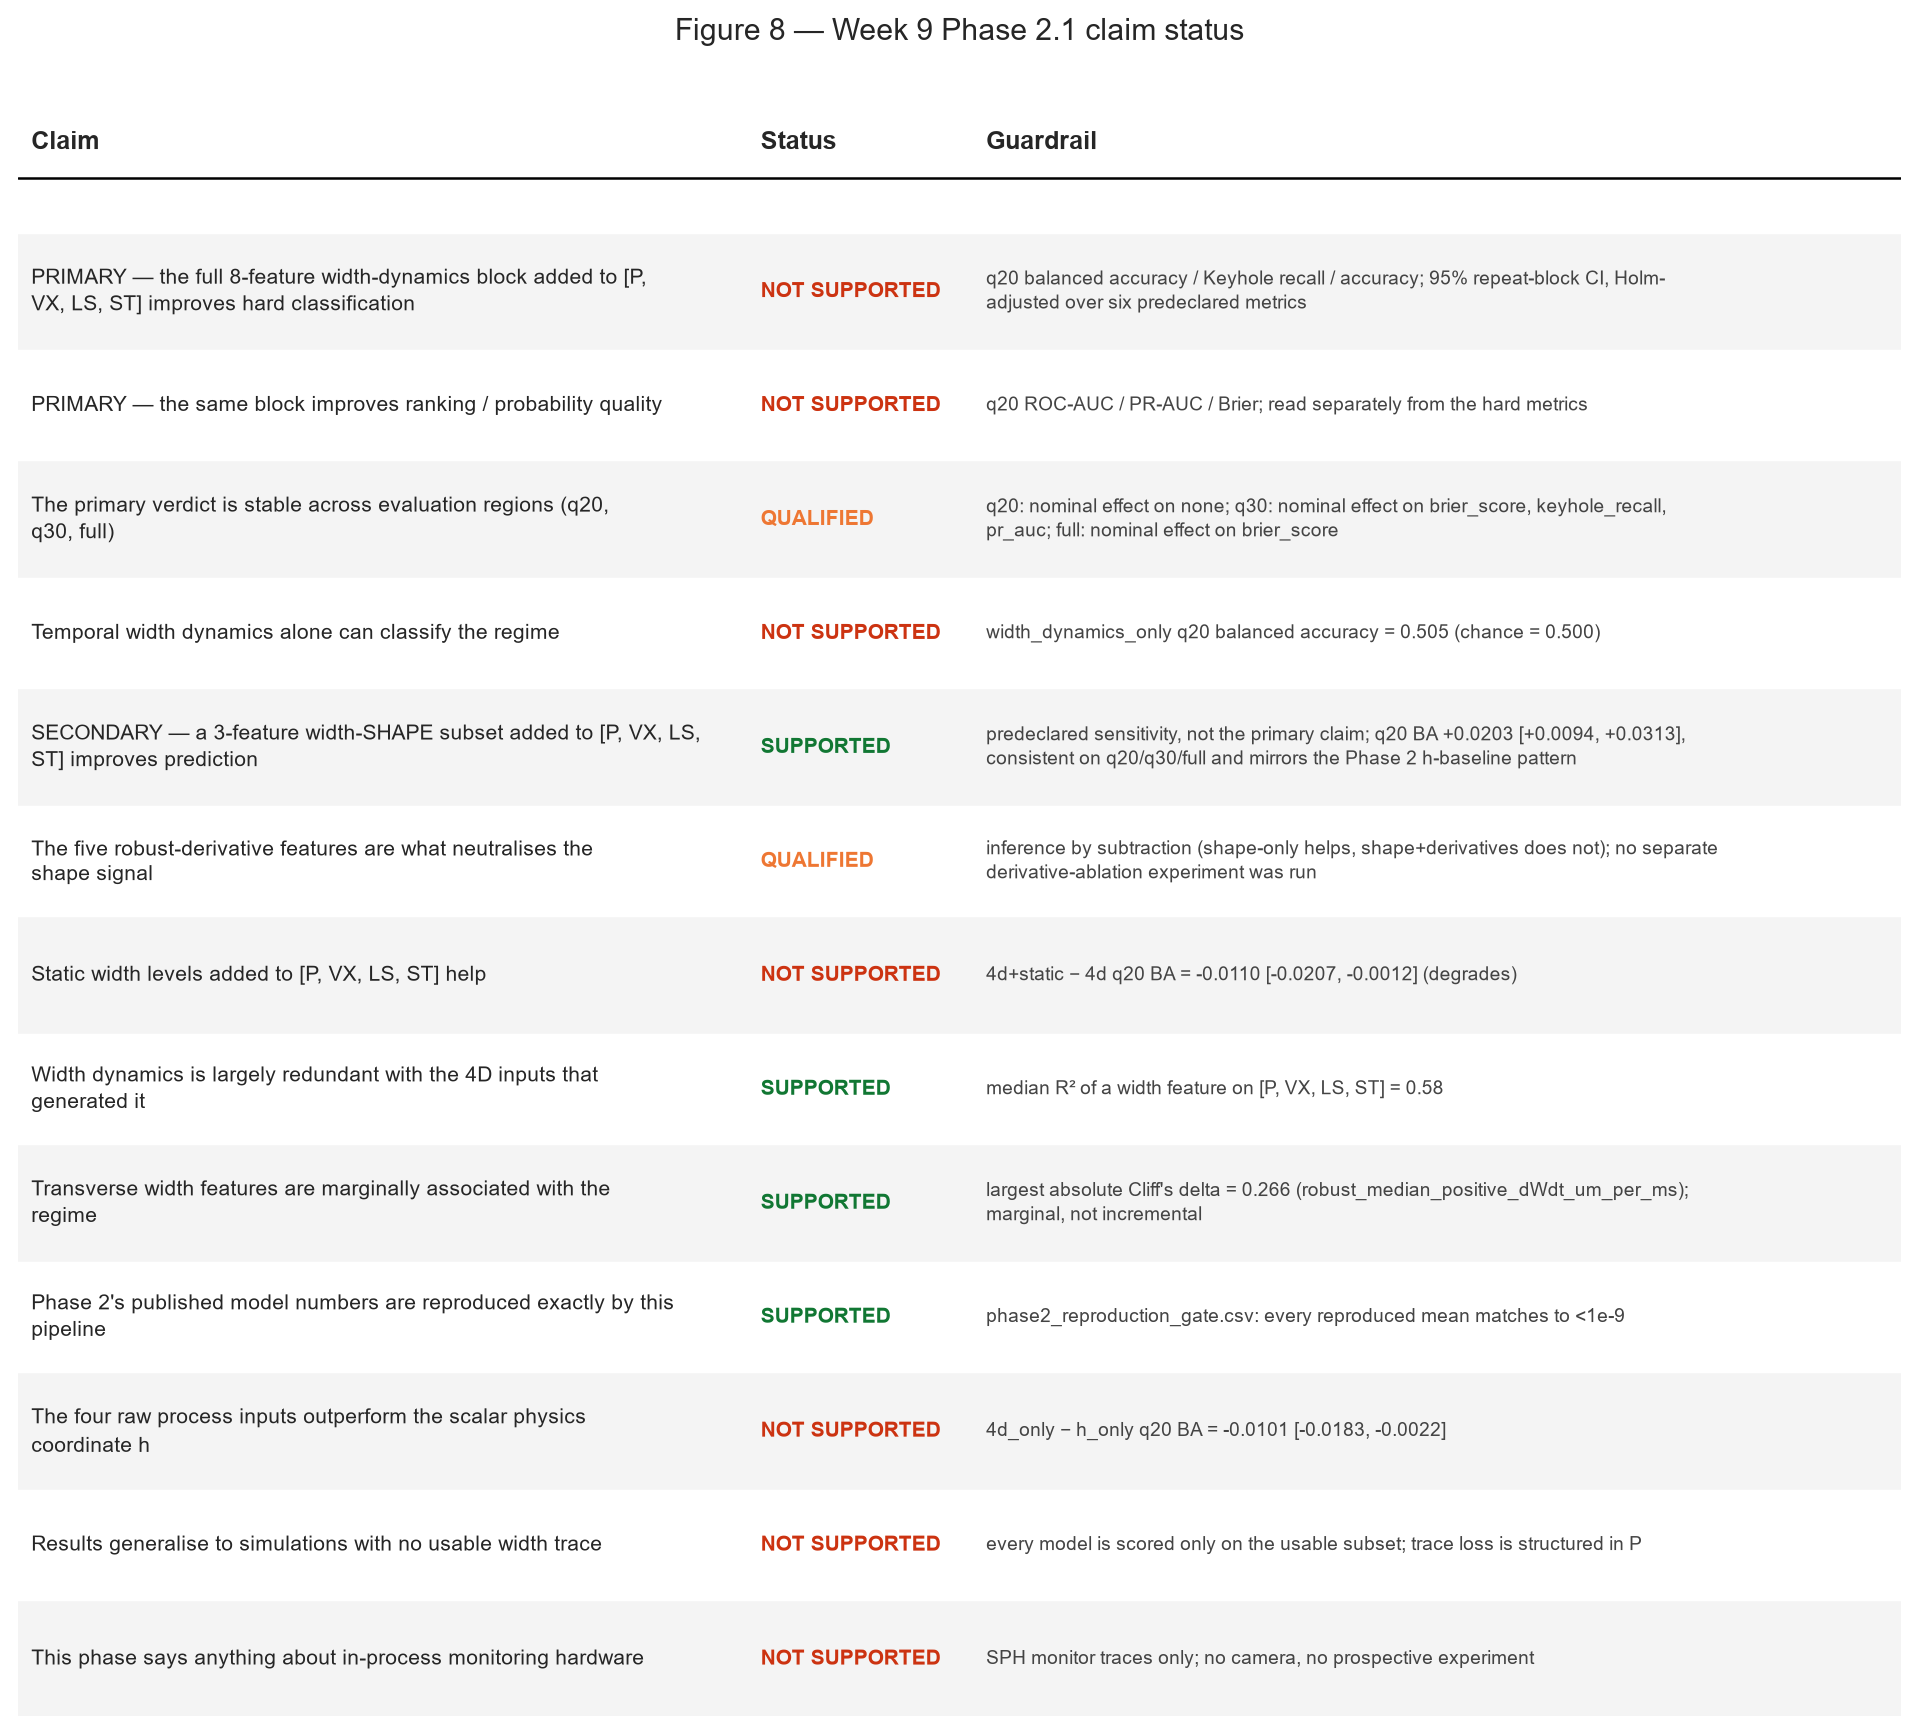

# Supervisor Phase 2.1 — one page

## The control Ioan asked for
Phase 2 tested width dynamics against the scalar physics coordinate `h`. It never ran the control an
engineer actually cares about: the baseline is the **four process parameters you dial on the machine**,
`[P, VX, LS, ST]`. Phase 2.1 runs exactly that comparison, with the width definition, population and
folds all held fixed.

* **Baseline** `4d_only` = `[P, VX, LS, ST]`
* **Challenger** `4d_plus_width_dynamics` = `[P, VX, LS, ST]` + the eight Phase 2 temporal width features
* Width is transverse **ΔY = Ymax − Ymin**, reused byte-for-byte from Phase 2 commit `da913797d14b`.
  ΔX (longitudinal length) is not used anywhere in this phase.

## Data
350 of 405 simulations have a usable transverse-width trace (70 Keyhole,
280 Conduction). Every model — baseline included — is trained and scored on that
same subset, so the comparison is paired. Trace loss is **not** random: usable simulations sit at higher
laser power (standardiz

In [8]:
display(Image(filename=OUT/'figures'/'08_claim_status.png'))
print((OUT/'SUPERVISOR_PHASE2_1_ONE_PAGE.md').read_text(encoding='utf-8'))


## 8. Interactive 3D process space (ST dropped from the axes)

`outputs/week9_phase2_1_fourd_plus_width_control/interactive_3d_process_space.html` is a self-contained offline view: axes `P`, `VX`, `LS`, colour = manual `has_keyhole`, hover gives the experiment ID, `ST`, `log_h`, the label and whether the trace was usable. Open it in any browser — it needs no libraries and no network.


In [9]:
html = OUT/'interactive_3d_process_space.html'
print(html.name, '|', round(html.stat().st_size/1024, 1), 'KB')
print('validation:', json.loads((OUT/'validation_report.json').read_text(encoding='utf-8'))['status'])


interactive_3d_process_space.html | 109.6 KB
validation: PASS
